In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
from jaxtyping import Float

import dismech_jax as djx

from util import *
from helpers import *
from animate import animate

jax.config.update("jax_enable_x64", True)

In [2]:
from Energy_NN_architectures import *

K_init = jnp.array([0.2, 0.0, 0.02])

# train_data = "../data/output_old.npz"
# valid_data = "../data/output_valid.npz"

train_data = "../data/combined_output_new_train.npz"
valid_data = "../data/combined_output_new_test.npz"

train_file = "training_data.npz"
valid_file = "validation_data.npz"
# convert to direct-BC format
convert_linear_bc_to_direct_bc(train_data, train_file, lambdas=None)
convert_linear_bc_to_direct_bc(valid_data, valid_file, lambdas=None)


Saved converted direct-BC dataset to: training_data.npz
qs.shape      = (2, 11, 11)
xb.shape      = (2, 11, 8)
idx_b.shape   = (8,)
lambdas.shape = (11,)
Saved converted direct-BC dataset to: validation_data.npz
qs.shape      = (2, 11, 11)
xb.shape      = (2, 11, 8)
idx_b.shape   = (8,)
lambdas.shape = (11,)


In [3]:
from properties import Properties

properties = Properties(
    length = 0.5,
    r0 = 0.005,
    axs = None,
    jxs = None,
    ixs1 = None,
    ixs2 = None,
    density = 800.0,
    E = 1e6,
    N = 3,
    # start = jax.numpy.array([0, 0, 0]),
    # end = jax.numpy.array([0.266166, 0., 0.01240256]),
    mass = 0.647
)

params = ModelParams(
    der_K=K_init,
    key=jax.random.PRNGKey(0),
    hidden=(10,),
    which_case="MLP",
    corr_factor=1,
    input_mode="raw",
    zero_reference=True,
    activation="tanh"
)

In [4]:

final_model, train_history, valid_history = train_model(properties=properties, model_cls=CholeskyPlusStiffnessSignedNN, params=params, train_file=train_file, valid_file=valid_file, n_epochs=5000, lr=5e-2)

Epoch 000 | Train: 9.278e-03 | Valid: 3.758e-04
Epoch 010 | Train: 2.826e-04 | Valid: 9.309e-04
Epoch 020 | Train: 3.413e-03 | Valid: 2.685e-03
Epoch 030 | Train: 2.393e-03 | Valid: 2.490e-03
Epoch 040 | Train: 1.550e-03 | Valid: 1.942e-03
Epoch 050 | Train: 1.144e-03 | Valid: 1.397e-03
Epoch 060 | Train: 7.020e-04 | Valid: 7.833e-04
Epoch 070 | Train: 2.107e-04 | Valid: 1.400e-04
Epoch 080 | Train: 7.920e-05 | Valid: 1.257e-04
Epoch 090 | Train: 6.577e-05 | Valid: 8.299e-05
Epoch 100 | Train: 5.415e-05 | Valid: 5.461e-05
Epoch 110 | Train: 4.867e-05 | Valid: 5.370e-05
Epoch 120 | Train: 4.567e-05 | Valid: 5.939e-05
Epoch 130 | Train: 4.280e-05 | Valid: 5.303e-05
Epoch 140 | Train: 4.083e-05 | Valid: 4.929e-05
Epoch 150 | Train: 3.866e-05 | Valid: 4.873e-05
Epoch 160 | Train: 3.670e-05 | Valid: 4.691e-05
Epoch 170 | Train: 3.478e-05 | Valid: 4.456e-05
Epoch 180 | Train: 3.290e-05 | Valid: 4.289e-05
Epoch 190 | Train: 3.108e-05 | Valid: 4.109e-05
Epoch 200 | Train: 2.930e-05 | Valid: 3.

5000


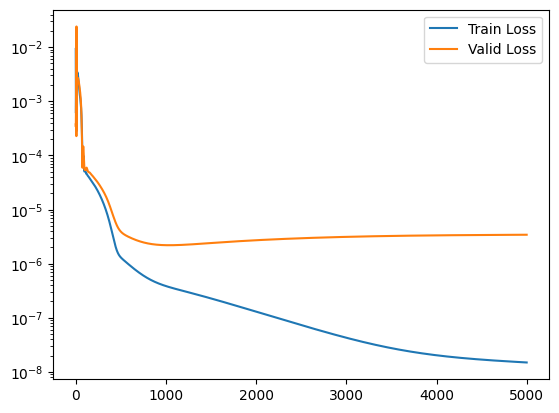

In [5]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

print(len(train_history))

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [6]:
base, aux = get_slinky(properties)
valid = Dataset.load(valid_file)
pred = predict(final_model, base, aux, valid.idx_b, valid.xb, valid.lambdas)

In [7]:
animate(pred[0])


In [8]:

animate(valid.qs[0])

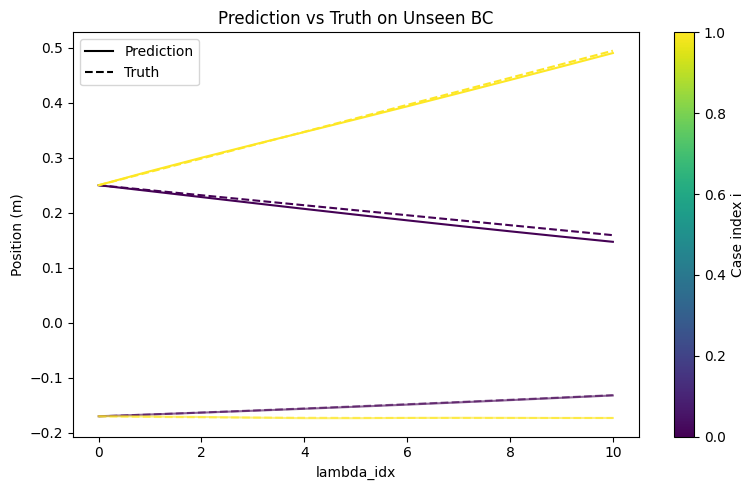

In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import jax.numpy as jnp

n_cases = pred.shape[0]
colors = cm.viridis(jnp.linspace(0, 1, n_cases))

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n_cases):
    c = colors[i]

    # X
    ax.plot(pred[i, :, 4], color=c, linestyle='-')
    ax.plot(valid.qs[i, :, 4], color=c, linestyle='--')

    # Z
    ax.plot(pred[i, :, 6], color=c, linestyle='-', alpha=0.6)
    ax.plot(valid.qs[i, :, 6], color=c, linestyle='--', alpha=0.6)

pred_line = mlines.Line2D([], [], color='black', linestyle='-', label='Prediction')
truth_line = mlines.Line2D([], [], color='black', linestyle='--', label='Truth')
ax.legend(handles=[pred_line, truth_line])

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=n_cases - 1))
sm.set_array([])  # helps matplotlib know this is a valid mappable
fig.colorbar(sm, ax=ax, label='Case index i')

ax.set_title("Prediction vs Truth on Unseen BC")
ax.set_xlabel("lambda_idx")
ax.set_ylabel("Position (m)")
fig.tight_layout()
plt.show()

In [10]:
train = Dataset.load(train_file)
pred = predict(final_model, base, aux, train.idx_b, train.xb, train.lambdas)

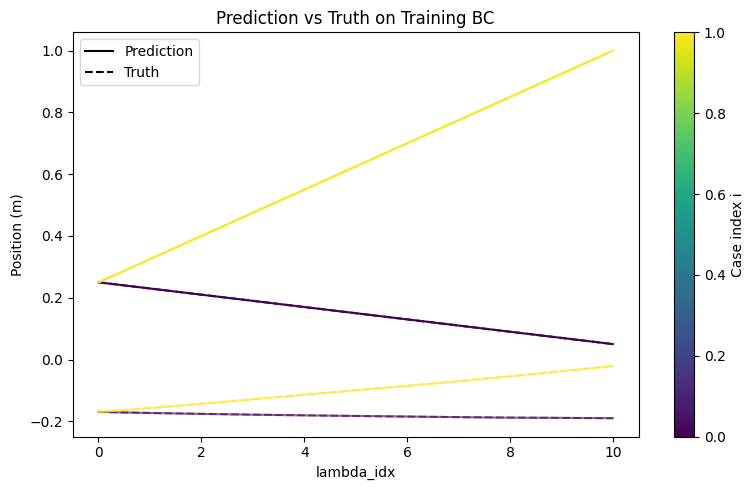

In [11]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import jax.numpy as jnp

n_cases = pred.shape[0]
colors = cm.viridis(jnp.linspace(0, 1, n_cases))

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n_cases):
    c = colors[i]

    # X
    ax.plot(pred[i, :, 4], color=c, linestyle='-')
    ax.plot(train.qs[i, :, 4], color=c, linestyle='--')

    # Z
    ax.plot(pred[i, :, 6], color=c, linestyle='-', alpha=0.6)
    ax.plot(train.qs[i, :, 6], color=c, linestyle='--', alpha=0.6)

pred_line = mlines.Line2D([], [], color='black', linestyle='-', label='Prediction')
truth_line = mlines.Line2D([], [], color='black', linestyle='--', label='Truth')
ax.legend(handles=[pred_line, truth_line])

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=n_cases - 1))
sm.set_array([])  # helps matplotlib know this is a valid mappable
fig.colorbar(sm, ax=ax, label='Case index i')

ax.set_title("Prediction vs Truth on Training BC")
ax.set_xlabel("lambda_idx")
ax.set_ylabel("Position (m)")
fig.tight_layout()
plt.show()